## Data loading

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import ast
import warnings
import pickle

In [ ]:
# CONSTANTS AND PATHS
TRAIN_DIR = "data/BBDD"
TEST_DIR = "data/qsd1_w1"

In [12]:
def build_dataset(dataset_dir):
    """
    Build a dataset of images and their corresponding labels from a given directory.

    Parameters:
    dataset_dir (str): The path to the directory containing the dataset.

    Returns:
    pd.DataFrame: A DataFrame containing the image paths and their corresponding labels.
    """
    data = {}

    for file in os.listdir(dataset_dir):

        # Get filename without extension
        filename = os.path.splitext(file)[0]
        filetype = os.path.splitext(file)[1]

        # Create entry if it doesn't already exist
        if filename not in data and filetype != '.pkl':
            data[filename] = {
                "image_name": None,
                "image_path": None,  
                "artist": None,
                "artwork_name": None
            }

        # Load image
        if file.lower().endswith(".jpg"):
            image_path = os.path.join(dataset_dir, file)

            data[filename]["image_path"] = image_path
            
            data[filename]["image_name"] = int(file.replace("bbdd_", "").replace(".jpg", ""))

        # Load label
        elif file.lower().endswith(".txt"):
            txt_path = os.path.join(dataset_dir, file)

            with open(txt_path, "r", encoding="latin1") as f:
                content = f.read().strip()

            # Empty .txt file
            if not content:
                continue

            try:
                lines = list(ast.literal_eval(content))

                if len(lines) >= 2:
                    data[filename]["artist"] = str(lines[0])
                    data[filename]["artwork_name"] = str(lines[1])

            except (ValueError, SyntaxError):
                print(f"Warning: Could not parse label file: {txt_path}")

    # Convert dictionary to DataFrame
    df = pd.DataFrame.from_dict(data, orient="index")

    # Reset index
    df = df.reset_index(drop=True)

    return df

In [16]:
df_bbdd = build_dataset(TRAIN_DIR)
print(df_bbdd.shape)
df_bbdd.head()

(287, 4)


,image_name,image_path,artist,artwork_name
0,0,data/BBDD\bbdd_00000.jpg,Victor Perez-Porros,Des-li-zan-tes
1,1,data/BBDD\bbdd_00001.jpg,Hugo Demarco,Reflecting Room
2,2,data/BBDD\bbdd_00002.jpg,None,None
3,3,data/BBDD\bbdd_00003.jpg,Edvard Munch,Youth
4,4,data/BBDD\bbdd_00004.jpg,Martin Carral,Ciclo espacial XXIV


In [ ]:
df_qsd1_w1 = build_dataset(TEST_DIR)

# erase artist and artwork_name
df_qsd1_w1 = df_qsd1_w1.drop(columns=['artist','artwork_name'])

# add correspondencies as a new colum 'ground_truth'
correspondence_path = os.path.join(TEST_DIR, "gt_corresps.pkl")
with open(correspondence_path, "rb") as file:
    correspondences = pickle.load(file)

df_qsd1_w1["ground_truth"] = (df_qsd1_w1["image_name"].map(lambda idx: correspondences[idx][0]))

print(df_qsd1_w1.shape)
df_qsd1_w1.head()

(30, 3)


,image_name,image_path,ground_truth
0,0,data/qsd1_w1\00000.jpg,120
1,1,data/qsd1_w1\00001.jpg,170
2,2,data/qsd1_w1\00002.jpg,277
3,3,data/qsd1_w1\00003.jpg,227
4,4,data/qsd1_w1\00004.jpg,251


## Descriptors

In [25]:
# build the histograms 
BINS = 256
EPS = 1e-10

# OpenCV conversion code + value range of each channel (8-bit images)
COLOR_SPACES = {
    "lab":   (cv2.COLOR_BGR2LAB,   [(0, 256), (0, 256), (0, 256)]),
    "ycbcr": (cv2.COLOR_BGR2YCrCb, [(0, 256), (0, 256), (0, 256)]),  # OpenCV order: Y, Cr, Cb
    "hsv":   (cv2.COLOR_BGR2HSV,   [(0, 180), (0, 256), (0, 256)]),  # H is 0-179 in OpenCV
}

def compute_histogram(image_path, color_space, bins=BINS):
    """
    Compute a 1D histogram per channel in the given color space,
    normalize each channel (L1) and concatenate the 3 of them.

    Returns:
    np.ndarray (float32) of shape (3 * bins,), sums to 1.
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    code, ranges = COLOR_SPACES[color_space]
    img = cv2.cvtColor(img, code)

    hists = []
    for ch, (low, high) in enumerate(ranges):
        h = cv2.calcHist([img], [ch], None, [high], [low, high])
        cv2.normalize(h, h, alpha=1, norm_type=cv2.NORM_L1)  # each channel sums to 1
        hists.append(h.ravel())

    # Divide by number of channels so the full histogram sums to 1
    return np.concatenate(hists)

In [28]:
CHANNEL_INFO = {
    "hsv":   (["H", "S", "V"],   ["tab:purple", "tab:green", "tab:gray"]),
    "lab":   (["L", "a", "b"],   ["tab:gray", "tab:red", "tab:blue"]),
    "ycbcr": (["Y", "Cr", "Cb"], ["tab:gray", "tab:red", "tab:blue"]),}

def plot_image_histograms(row, color_space="hsv", bins=None):
    names, colors = CHANNEL_INFO[color_space]
    ranges = COLOR_SPACES[color_space][1]
    sizes = [high - low for low, high in ranges]
    channels = np.split(row[f"hist_{color_space}"], np.cumsum(sizes)[:-1])

    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    axes[0].imshow(cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Image {row['image_name']}")
    axes[0].axis("off")

    for ax, hist, (low, high), name, color in zip(axes[1:], channels, ranges, names, colors):
        sns.histplot(x=np.arange(low, high), weights=hist, bins=bins or high - low,
                     binrange=(low, high), color=color, ax=ax)
        ax.set(title=f"{color_space.upper()} - {name}", xlabel="Value", ylabel="Frequency", xlim=(low, high))

    fig.tight_layout()
    plt.show()

In [26]:
for cs in COLOR_SPACES:
    df_bbdd[f"hist_{cs}"] = df_bbdd["image_path"].apply(lambda p: compute_histogram(p, cs))

In [27]:
df_bbdd.head()

,image_name,image_path,artist,artwork_name,hist_lab,hist_ycbcr,hist_hsv
0,0,data/BBDD\bbdd_00000.jpg,Victor Perez-Porros,Des-li-zan-tes,"[0.0013478914, 0.0076686703, 0.01111962, 0.009...","[0.0004882964, 0.0027866736, 0.0049999612, 0.0...","[0.022291454, 0.012597079, 0.015620649, 0.0165..."
1,1,data/BBDD\bbdd_00001.jpg,Hugo Demarco,Reflecting Room,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2,data/BBDD\bbdd_00002.jpg,None,None,"[0.0030003206, 0.015843296, 0.032053042, 0.017...","[0.0012940314, 0.0040996745, 0.012167331, 0.01...","[0.046167146, 0.0, 9.733864e-05, 0.00024048371..."
3,3,data/BBDD\bbdd_00003.jpg,Edvard Munch,Youth,"[5.2866628e-05, 0.00013866289, 0.0002979348, 0...","[2.5537269e-05, 7.235559e-05, 9.094852e-05, 0....","[0.0075388704, 0.0011173675, 0.001489674, 0.00..."
4,4,data/BBDD\bbdd_00004.jpg,Martin Carral,Ciclo espacial XXIV,"[2.0602781e-06, 6.867594e-07, 5.494075e-06, 6....","[0.0, 2.0602781e-06, 6.867594e-07, 0.0, 4.8073...","[0.01876364, 0.0016619577, 0.0027848093, 0.006..."


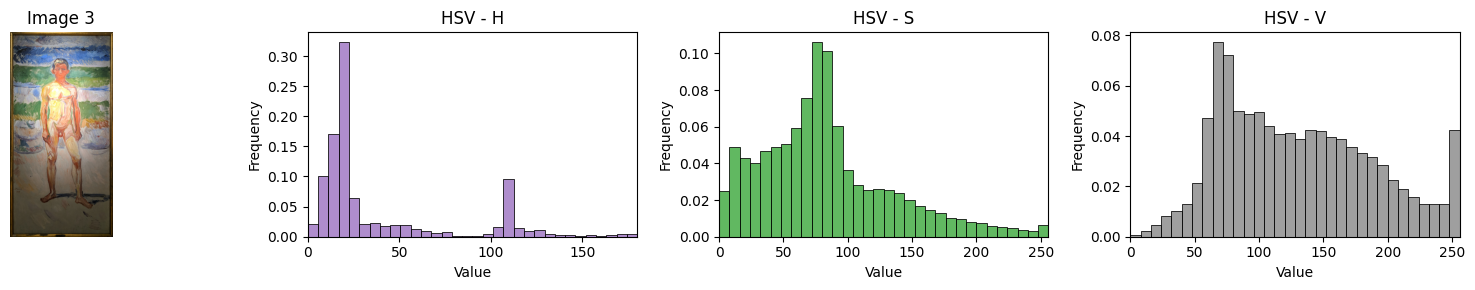

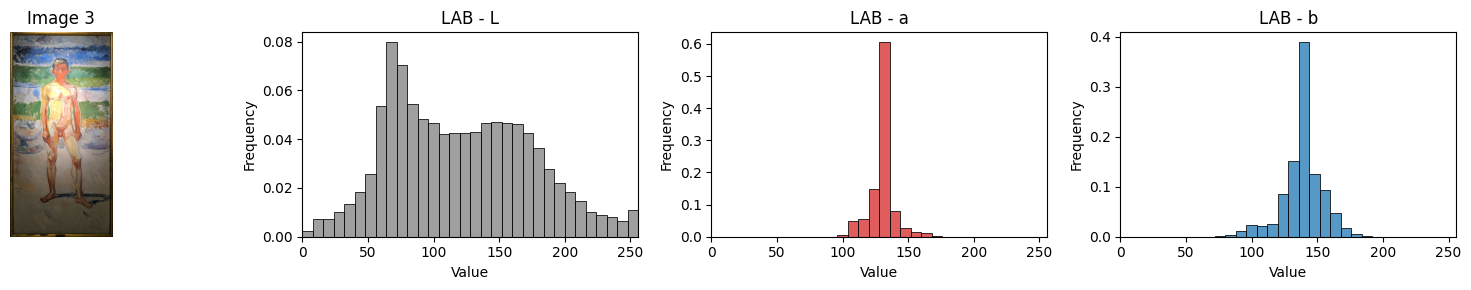

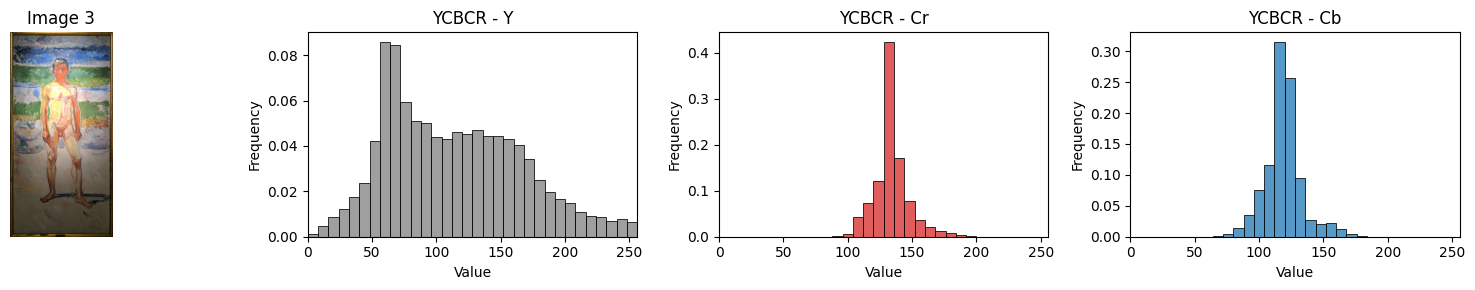

In [32]:
plot_image_histograms(df_bbdd.iloc[3], color_space="hsv", bins=32)
plot_image_histograms(df_bbdd.iloc[3], color_space="lab", bins=32)
plot_image_histograms(df_bbdd.iloc[3], color_space="ycbcr", bins=32)

## Distances

In [ ]:
SIMILARITIES = {"intersection", "hellinger"}   # higher = more similar
DISTANCES = {"euclidean", "l1", "x2", "chi_squared", "emd", "bhattacharyya"}  # lower = more similar



def _emd(h1, h2, n_channels=3, use_cv2=False):
    """
    Earth Mover's Distance, computed per channel and summed.
    For 1D histograms EMD has a closed form (L1 distance between CDFs).
    That is identical to cv2.EMD and much faster. Set use_cv2=True to use cv2.EMD.
    """
    total = 0.0
    for x, y in zip(h1.reshape(n_channels, -1), h2.reshape(n_channels, -1)):
        x = x / (x.sum() + EPS)
        y = y / (y.sum() + EPS)
        if use_cv2:
            idx = np.arange(len(x), dtype=np.float32)
            s1 = np.column_stack([x, idx]).astype(np.float32)  # signature: [weight, position]
            s2 = np.column_stack([y, idx]).astype(np.float32)
            d, _, _ = cv2.EMD(s1, s2, cv2.DIST_L1)
        else:
            d = np.abs(np.cumsum(x) - np.cumsum(y)).sum()
        total += d
    return float(total)


def compare_histograms(h1, h2, distance):
    h1 = np.asarray(h1, dtype=np.float32).ravel()
    h2 = np.asarray(h2, dtype=np.float32).ravel()

    if distance == "euclidean":
        return cv2.norm(h1, h2, cv2.NORM_L2)
    if distance == "l1":
        return cv2.norm(h1, h2, cv2.NORM_L1)
    if distance == "x2":
        # Symmetric X2: 2 * sum (h1-h2)^2 / (h1+h2)
        return cv2.compareHist(h1, h2, cv2.HISTCMP_CHISQR_ALT)
    if distance == "chi_squared":
        # Classic (Pearson) chi-squared: sum (h1-h2)^2 / h1
        return cv2.compareHist(h1, h2, cv2.HISTCMP_CHISQR)
    if distance == "intersection":
        # sum min(h1, h2)  -> similarity in [0, 1]
        return cv2.compareHist(h1, h2, cv2.HISTCMP_INTERSECT)
    if distance == "hellinger":
        # Hellinger kernel: sum sqrt(h1 * h2) -> similarity in [0, 1]
        return float(np.sum(np.sqrt(h1 * h2)))
    if distance == "emd":
        return _emd(h1, h2)
    if distance == "bhattacharyya":
        # Classic Bhattacharyya distance: -ln( sum sqrt(h1 * h2) )
        return float(-np.log(np.sum(np.sqrt(h1 * h2)) + EPS))

    raise ValueError(f"Unknown distance '{distance}'. Options: {sorted(SIMILARITIES | DISTANCES)}")

In [ ]:
def compute_distances(query_hist, museum_hists, metric="l1"):
    """
    Compute the distance between one query histogram and all the museum histograms.

    Lower value = more similar, for every metric.

    Parameters:
    query_hist (np.ndarray): Query histogram, shape (3, bins).
    museum_hists (np.ndarray): Museum histograms, shape (n_museum, 3, bins).
    metric (str): One of METRICS.

    Returns:
    np.ndarray: Distances of shape (n_museum,).
    """
    n_channels = query_hist.shape[0]

    # EMD in 1D has a closed form: L1 distance between the cumulative histograms.
    # It is computed per channel (bins are ordered) and summed over channels.
    if metric == "emd":
        cdf_diff = np.cumsum(museum_hists, axis=2) - np.cumsum(query_hist, axis=1)[None]
        return np.abs(cdf_diff).sum(axis=2).sum(axis=1)

    # For the remaining metrics concatenate the channels and renormalize so the
    # vector is a probability distribution (sum = 1).
    q = query_hist.reshape(-1) / n_channels
    m = museum_hists.reshape(len(museum_hists), -1) / n_channels

    if metric == "euclidean":
        return np.sqrt(((q - m) ** 2).sum(axis=1))

    if metric == "l1":
        return np.abs(q - m).sum(axis=1)

    if metric == "chi2":
        # Symmetric chi-square distance (cv2.HISTCMP_CHISQR_ALT, up to a factor)
        return 0.5 * (((q - m) ** 2) / (q + m + EPS)).sum(axis=1)

    if metric == "x2":
        # Classic (asymmetric) chi-square, cv2.HISTCMP_CHISQR: query is the reference
        return (((q - m) ** 2) / (q + EPS)).sum(axis=1)

    if metric == "intersection":
        # Histogram intersection is a similarity in [0, 1] -> turn it into a distance
        return 1.0 - np.minimum(q, m).sum(axis=1)

    if metric in ("bhattacharyya", "hellinger"):
        bc = np.sqrt(q * m).sum(axis=1)  # Bhattacharyya coefficient in [0, 1]
        if metric == "bhattacharyya":
            return -np.log(np.maximum(bc, EPS))      # classic Bhattacharyya distance
        return np.sqrt(np.maximum(1.0 - bc, 0.0))    # Hellinger distance

    raise ValueError(f"Unknown metric '{metric}'. Use one of {METRICS}")


In [ ]:
# pip install ml_metrics
import ml_metrics as metrics

with open(os.path.join(TEST_DIR, "gt_corresps.pkl"), "rb") as f:
    gt = pickle.load(f)
gt = [g if isinstance(g, (list, tuple)) else [g] for g in gt]

def evaluate(histogram, distance, k=5):
    predicted, actual = [], []
    for name in df_qsd1_w1["image_name"]:
        predicted.append(retrieve_similar(name, histogram, distance, k)["image_name"].tolist())
        actual.append(list(gt[name]))
    return metrics.mapk(actual, predicted, k)

results = pd.DataFrame(
    {cs: {d: evaluate(cs, d, k=5) for d in sorted(SIMILARITIES | DISTANCES)} for cs in COLOR_SPACES}
)
results

# Visualization

In [ ]:

# --------------------------------------------------------------------------- #
# 6. Visualization
# --------------------------------------------------------------------------- #
# Channel names and plotting colors for each color space
CHANNEL_INFO = {
    "hsv":   (["H", "S", "V"],   ["tab:purple", "tab:green", "tab:gray"]),
    "lab":   (["L", "a", "b"],   ["tab:gray", "tab:red", "tab:blue"]),
    "ycbcr": (["Y", "Cr", "Cb"], ["tab:gray", "tab:red", "tab:blue"]),
}
 
 
def plot_histogram(hist, color_space="hsv", axes=None, title=None, color=None, alpha=1.0, label=None):
    """
    Plot the per-channel 1D histograms of a (3, bins) histogram array.
 
    Parameters:
    hist (np.ndarray): Histogram of shape (3, bins), as returned by compute_histogram_1d.
    color_space (str): Color space the histogram was computed in (sets names and ranges).
    axes (list[plt.Axes] | None): Three axes to draw on. If None, a new figure is created.
    title (str | None): Title of the figure (only used when creating a new figure).
    color (str | None): Force one color for all channels (useful for overlays).
    alpha (float): Bar transparency.
    label (str | None): Legend label.
 
    Returns:
    list[plt.Axes]: The three axes used.
    """
    names, colors = CHANNEL_INFO[color_space]
    ranges = COLOR_SPACES[color_space][1]
    bins = hist.shape[1]
 
    if axes is None:
        fig, axes = plt.subplots(1, 3, figsize=(12, 3))
        if title:
            fig.suptitle(title)
 
    for channel, ax in enumerate(axes):
        low, high = ranges[channel]
        edges = np.linspace(low, high, bins + 1)
        ax.bar(edges[:-1], hist[channel], width=(high - low) / bins, align="edge",
               color=color or colors[channel], alpha=alpha, label=label)
        ax.set_xlim(low, high)
        ax.set_title(f"{color_space.upper()} - {names[channel]}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
 
    return list(axes)
 
 
def plot_image_histograms(image, color_space="hsv", bins=32):
    """
    Show an image next to its 1D histograms in a given color space.
 
    Parameters:
    image (np.ndarray): BGR image, as loaded by cv2.imread.
    color_space (str): One of 'hsv', 'lab', 'ycbcr'.
    bins (int): Number of bins per channel.
 
    Returns:
    plt.Figure: The created figure.
    """
    hist = compute_histogram_1d(image, color_space, bins)
 
    fig, axes = plt.subplots(1, 4, figsize=(16, 3), gridspec_kw={"width_ratios": [1, 1.3, 1.3, 1.3]})
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Image")
    axes[0].axis("off")
 
    plot_histogram(hist, color_space, axes=axes[1:])
    fig.tight_layout()
 
    return fig
 
 
def plot_color_space_comparison(image, bins=32):
    """
    Show the histograms of one image in every color space (one row per color space).
 
    Parameters:
    image (np.ndarray): BGR image, as loaded by cv2.imread.
    bins (int): Number of bins per channel.
 
    Returns:
    plt.Figure: The created figure.
    """
    fig, axes = plt.subplots(len(COLOR_SPACES), 4, figsize=(16, 3 * len(COLOR_SPACES)),
                             gridspec_kw={"width_ratios": [1, 1.3, 1.3, 1.3]})
 
    for row, color_space in enumerate(COLOR_SPACES):
        axes[row, 0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title("Image")
        axes[row, 0].axis("off")
 
        hist = compute_histogram_1d(image, color_space, bins)
        plot_histogram(hist, color_space, axes=axes[row, 1:])
 
    fig.tight_layout()
 
    return fig
 
 
def plot_histogram_comparison(hist_a, hist_b, color_space="hsv", labels=("Query", "Museum")):
    """
    Overlay two histograms channel by channel, to see why two images are (dis)similar.
 
    Parameters:
    hist_a (np.ndarray): First histogram, shape (3, bins).
    hist_b (np.ndarray): Second histogram, shape (3, bins).
    color_space (str): Color space of the histograms.
    labels (tuple[str, str]): Legend labels.
 
    Returns:
    plt.Figure: The created figure.
    """
    fig, axes = plt.subplots(1, 3, figsize=(12, 3))
 
    plot_histogram(hist_a, color_space, axes=axes, color="tab:blue", alpha=0.6, label=labels[0])
    plot_histogram(hist_b, color_space, axes=axes, color="tab:orange", alpha=0.6, label=labels[1])
    axes[0].legend()
    fig.tight_layout()
 
    return fig
 
 
def plot_retrieval_results(query_df, museum_df, query_idx, indices, distances,
                           label_col="artwork_name"):
    """
    Show a query image followed by its retrieved museum images, in rank order.
 
    The title of each retrieved image shows the rank and the distance; it is green
    if the label matches the query label and red otherwise (black if no label).
 
    Parameters:
    query_df (pd.DataFrame): Query dataset.
    museum_df (pd.DataFrame): Museum dataset.
    query_idx (int): Row of the query to display.
    indices (np.ndarray): Retrieved indices, shape (n_query, k), from retrieve_top_k.
    distances (np.ndarray): Retrieved distances, shape (n_query, k), from retrieve_top_k.
    label_col (str): Column used to decide whether a result is correct.
 
    Returns:
    plt.Figure: The created figure.
    """
    k = indices.shape[1]
    fig, axes = plt.subplots(1, k + 1, figsize=(2.6 * (k + 1), 3.2))
 
    axes[0].imshow(cv2.cvtColor(query_df["image"].iloc[query_idx], cv2.COLOR_BGR2RGB))
    axes[0].set_title("Query", fontweight="bold")
    axes[0].axis("off")
 
    query_label = query_df[label_col].iloc[query_idx]
 
    for rank in range(k):
        museum_idx = indices[query_idx, rank]
        museum_label = museum_df[label_col].iloc[museum_idx]
 
        if pd.isna(query_label):
            color = "black"
        else:
            color = "green" if museum_label == query_label else "red"
 
        ax = axes[rank + 1]
        ax.imshow(cv2.cvtColor(museum_df["image"].iloc[museum_idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f"#{rank + 1}  d={distances[query_idx, rank]:.3f}", color=color, fontsize=10)
        ax.axis("off")
 
    fig.tight_layout()
 
    return fig
 
 
def plot_results_heatmap(results, metric_col="precision@10"):
    """
    Plot a color space x distance heatmap of an evaluation metric.
 
    Parameters:
    results (pd.DataFrame): Output of run_experiments.
    metric_col (str): Column of `results` to display (e.g. 'hit@1', 'precision@10').
 
    Returns:
    plt.Figure: The created figure.
    """
    table = results.pivot(index="color_space", columns="metric", values=metric_col)
 
    fig, ax = plt.subplots(figsize=(10, 3))
    im = ax.imshow(table.values, cmap="viridis", aspect="auto")
 
    ax.set_xticks(range(table.shape[1]), table.columns, rotation=30)
    ax.set_yticks(range(table.shape[0]), table.index)
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            ax.text(j, i, f"{table.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=9)
 
    ax.set_title(metric_col)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
 
    return fig
 